In [ ]:
from langgraph.graph import StateGraph, START, END

from typing_extensions import TypedDict, NotRequired

from spm_agent.states.image_analysis_state import ImageAnalysisState

from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node
from spm_agent.nodes.agentic_segmentation_node import agentic_segmentation_node
from spm_agent.nodes.set_experiment_tasks_node import make_experiment_tasks_node
from spm_agent.nodes.importance_map_node import importance_map_node


In [2]:
EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    "Study wall-mediated switching"
]

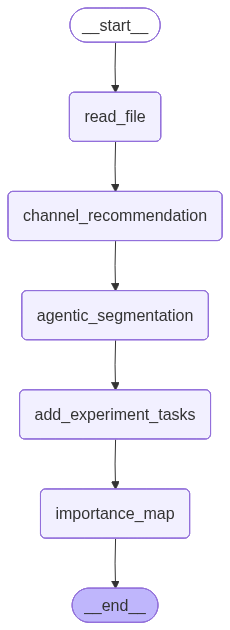

In [6]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)
builder.add_node("channel_recommendation", channel_recommendation_node)
builder.add_node("agentic_segmentation", agentic_segmentation_node)
builder.add_node("add_experiment_tasks", make_experiment_tasks_node(EXPERIMENT_TASKS)) # type: ignore
builder.add_node("importance_map", importance_map_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", "channel_recommendation")
builder.add_edge("channel_recommendation", "agentic_segmentation")
builder.add_edge("agentic_segmentation", "add_experiment_tasks")
builder.add_edge("add_experiment_tasks", "importance_map")
builder.add_edge("importance_map", END)

im_graph = builder.compile()
im_graph

In [8]:
result = await im_graph.ainvoke(
    {
        "file_path": r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw",
    }
)

In [9]:
# --- Cell: importance-map visualization helpers ---
import numpy as np
import matplotlib.pyplot as plt


def _view01(a, p=(1, 99)):
    """Robust [0,1] view of a channel for use as a grayscale backdrop."""
    a = a.astype(float); f = a[np.isfinite(a)]
    lo, hi = np.percentile(f, p) if f.size else (0.0, 1.0)
    return np.clip((a - lo) / (hi - lo + 1e-12), 0, 1)


def show_importance_map(result, ax=None):
    """Bare heatmap of one importance map, titled by its experiment task."""
    m = np.load(result["importance_map_path"])
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(m, cmap="inferno", vmin=0, vmax=100)
    ax.set_title(result["experiment_task"], fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")
    return ax


def compare_importance_maps(results):
    """All maps side by side — quick way to see they differ per task."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, results):
        show_importance_map(r, ax=ax)
    plt.tight_layout(); plt.show()


def show_importance_over_channel(result, channel_array_path, mask_paths=None, alpha=0.55):
    """Channel grayscale + importance heatmap overlaid, with optional mask contours."""
    ch = _view01(np.load(channel_array_path))
    m  = np.load(result["importance_map_path"])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(ch, cmap="gray")
    im = ax.imshow(np.ma.masked_less(m, 1), cmap="inferno", vmin=0, vmax=100, alpha=alpha)
    for mp in (mask_paths or []):
        ax.contour(np.load(mp).astype(float), levels=[0.5], colors="cyan", linewidths=0.6)
    ax.set_title(result["experiment_task"], fontsize=9); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")
    plt.show()


def region_importance(result, mask_paths: dict):
    """Mean importance per named region, e.g. {'domain': path, 'wall': path}. + background."""
    m = np.load(result["importance_map_path"])
    masks = {k: np.load(v).astype(bool) for k, v in mask_paths.items()}
    out = {k: (round(float(m[mk].mean()), 1) if mk.any() else None) for k, mk in masks.items()}
    bg = ~np.logical_or.reduce(list(masks.values())) if masks else np.ones_like(m, bool)
    out["background"] = round(float(m[bg].mean()), 1)
    return out


def show_top_peaks(result, channel_array_path, k=5, min_sep=15):
    """Preview of the deferred deterministic pick: greedy top-k peaks with a pixel min-separation."""
    m = np.load(result["importance_map_path"]); mm = m.copy()
    H, W = m.shape; yy, xx = np.ogrid[:H, :W]; pts = []
    for _ in range(k):
        r, c = np.unravel_index(np.argmax(mm), mm.shape)
        pts.append((int(r), int(c)))
        mm[(yy - r) ** 2 + (xx - c) ** 2 <= min_sep ** 2] = -1
    ch = _view01(np.load(channel_array_path))
    fig, ax = plt.subplots(figsize=(6, 6)); ax.imshow(ch, cmap="gray")
    ax.imshow(np.ma.masked_less(m, 1), cmap="inferno", vmin=0, vmax=100, alpha=0.5)
    for i, (r, c) in enumerate(pts):
        ax.plot(c, r, "o", mfc="none", mec="cyan", ms=14, mew=2)
        ax.text(c + 4, r, str(i + 1), color="cyan", fontsize=9)
    ax.set_title(f"{result['experiment_task']} — top {k}", fontsize=9); ax.axis("off"); plt.show()
    return pts

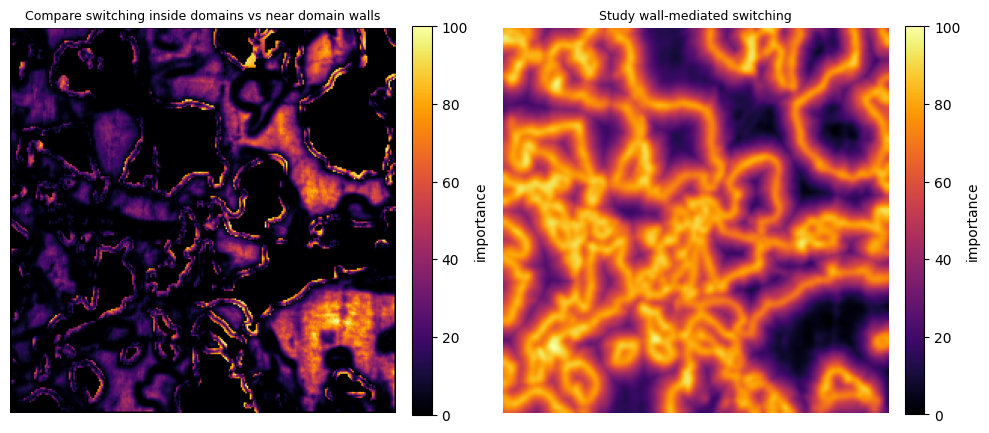

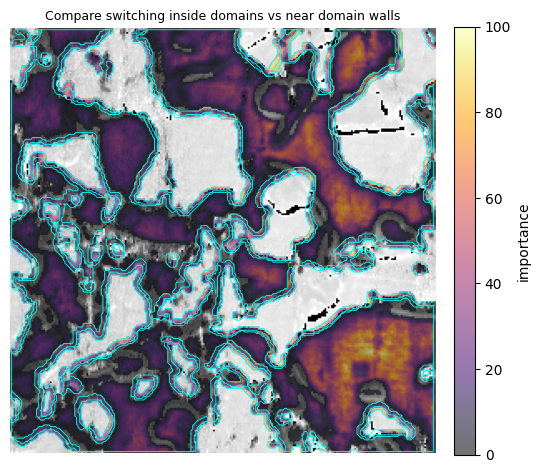

map_0 by region: {'domain': 16.7, 'wall': 21.2, 'background': 0.0}
map_1 by region: {'domain': 49.9, 'wall': 78.2, 'background': 52.9}


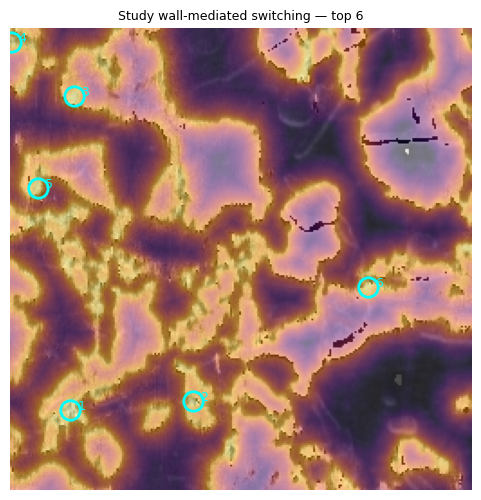

[(211, 33), (206, 101), (37, 35), (7, 0), (88, 15), (143, 198)]

In [10]:
# --- Cell: usage (paths from state, cwd-independent) ---
maps     = result["importance_maps"]
channels = result["file_channels"]
seg      = result["segmentation_results"]

phase = channels["Channel_003"]["array_path"]                       # absolute
dom   = seg["ferroelectric domain segmentation"]["mask_path"]       # absolute
wall  = seg["ferroelectric domain wall segmentation"]["mask_path"]  # absolute

compare_importance_maps(maps)
show_importance_over_channel(maps[0], phase, mask_paths=[dom, wall])
print("map_0 by region:", region_importance(maps[0], {"domain": dom, "wall": wall}))
print("map_1 by region:", region_importance(maps[1], {"domain": dom, "wall": wall}))
show_top_peaks(maps[1], phase, k=6, min_sep=15)

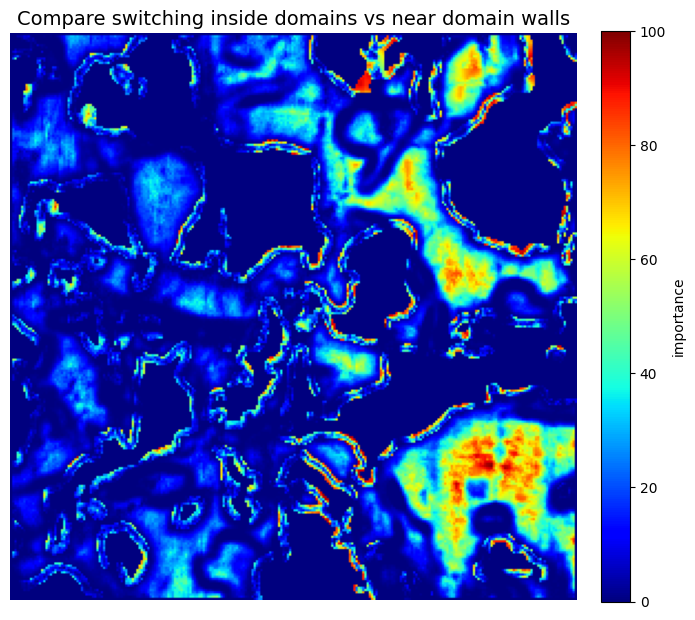

In [17]:

j = 0
m = np.load(result['importance_maps'][j]['importance_map_path'])

_, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(m, cmap="jet", vmin=0, vmax=100)
ax.set_title(result['importance_maps'][j]['experiment_task'], fontsize=14)
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")

In [18]:
from IPython.display import display, Markdown

def show_reasoning(result):
    display(Markdown(f"### {result['experiment_task']}\n\n{result['reasoning']}"))

for r in maps:
    show_reasoning(r)

### Compare switching inside domains vs near domain walls

The `importance_map.npy` has been saved. Here is a summary of the criteria and reasoning:

---

**Criteria and Rationale**

The task is to compare ferroelectric switching behaviour *inside* domains versus *near* domain walls, so the map must highlight high-quality measurement sites of **both** types simultaneously.

**Two location channels were constructed and combined with a pixel-wise maximum:**

1. **Domain-wall channel** — pixels inside the `wall_mask` are scored by (i) PFM amplitude (Amplitude2, normalised within the wall population, since walls intrinsically have lower amplitude due to polarisation cancellation) × (ii) topographic flatness (inverse local height roughness). This rewards wall pixels that still carry a measurable PFM signal on a smooth surface, making them reliable for local switching spectroscopy.

2. **Domain-interior channel** — pixels inside the `domain_mask` but outside the wall, weighted by (i) a sigmoid distance-from-wall score (rises steeply beyond ~5 px, ensuring the site is genuinely "inside" a domain and not in the transition zone) × (ii) PFM amplitude (global normalisation) × (iii) local phase uniformity (low spatial variance of Phase2 = well-defined, single-polarity domain state) × (iv) topographic flatness. This selects spots that are unambiguously within a single domain and have a strong, coherent PFM response.

**Why these criteria serve the task:** Switching spectroscopy (e.g., local PV loops) requires a stable, well-defined starting polarisation state (→ phase uniformity), a detectable piezoelectric signal (→ amplitude), and minimal topographic cross-talk (→ height flatness). The bimodal structure of the map — bright bands along walls *and* bright patches in domain interiors — directly provides paired measurement candidates for the intended comparison, while suppressing ambiguous transition zones and topographically rough regions.

### Study wall-mediated switching

The importance map is well-formed and correctly highlights the domain wall network. The `importance_map.npy` is saved and ready.

---

## Criteria and Rationale

The importance map for **wall-mediated switching** was built from six criteria combined as a weighted sum, then scaled to 0–100:

1. **Wall proximity (w = 0.35)** — The dominant criterion. Wall-mediated switching is, by definition, initiated at or propagated through domain walls. A Gaussian decay (σ = 8 px) from the segmented wall pixels ensures the highest scores sit on and immediately adjacent to walls, capturing the zone where tip-induced nucleation is most likely to couple to wall motion.

2. **Low PFM amplitude (w = 0.20)** — In dual-frequency PFM, amplitude minima mark regions of mixed or cancelled polarization — the hallmark of a domain wall. Pixels with suppressed amplitude (both Amp1 and Amp2) are confirmed wall/transition zones with the highest susceptibility to switching.

3. **Phase2 gradient magnitude (w = 0.20)** — A steep local gradient in the out-of-plane PFM phase indicates a sharp, well-defined polarization boundary. Sharp walls are the most tractable targets for studying switching dynamics and wall displacement under an applied field.

4. **Wall geometric curvature (w = 0.10)** — Kinked, curved, or branching wall segments (detected via the Laplacian of the smoothed wall mask) are preferential nucleation sites because local curvature concentrates the depolarisation field and lowers the switching barrier.

5. **Local phase2 variance (w = 0.10)** — High local variance in Phase2 signals regions where polarisation is disordered or competing between states — indicative of frustrated or partially switched areas that are prime candidates for wall-mediated switching events.

6. **Frequency gradient (w = 0.05)** — Local anomalies in the contact-resonance frequency near walls reflect changes in local stiffness or electromechanical coupling, providing a secondary indicator of mechanically distinct wall regions.